
# Questions to Answer
1. What are the most demanded skills for the top 3 most popular data roles?  
2. How are in-demand skills trending for Data and Business Analysts?  
3. How well do jobs and skills pay for Data and Business Analysts?  
4. What is the most optimal skill to learn for Data and Business Analysts? (High Demand AND High Paying)

# Exploratory Data Analysis for all Data Roles

In [3]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

In [4]:
#Load Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [4]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

In [4]:
#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Text(0, 0.5, '')

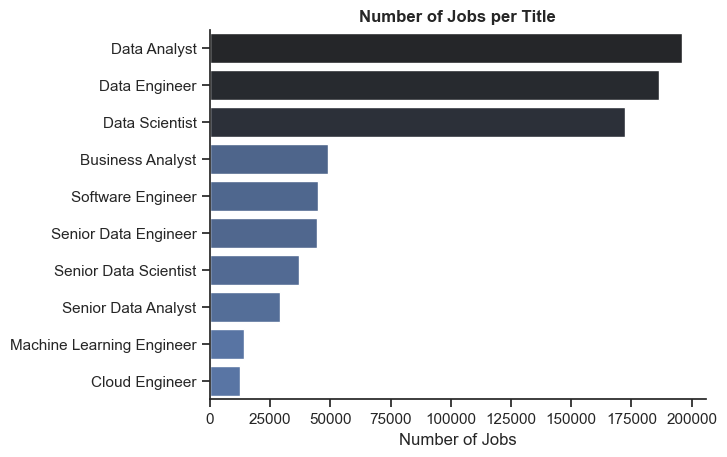

In [6]:
#Plot Count of Job title
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style = 'ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Number of Jobs per Title', fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('')

In [7]:
#Limit data to Malaysia
df_my = df[df['job_country']=='Malaysia']

Text(0, 0.5, '')

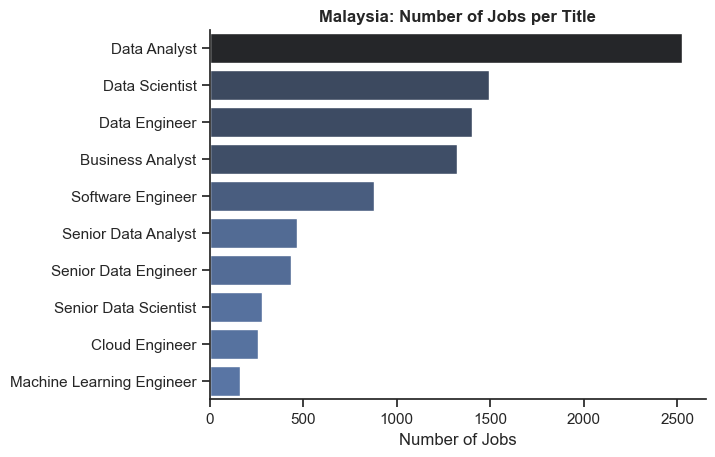

In [8]:
#Plot Count of Job title
df_plot_my = df_my['job_title_short'].value_counts().to_frame()

sns.set_theme(style = 'ticks')
sns.barplot(data=df_plot_my, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)

sns.despine()
plt.title('Malaysia: Number of Jobs per Title', fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('')

# Data Roles by Country

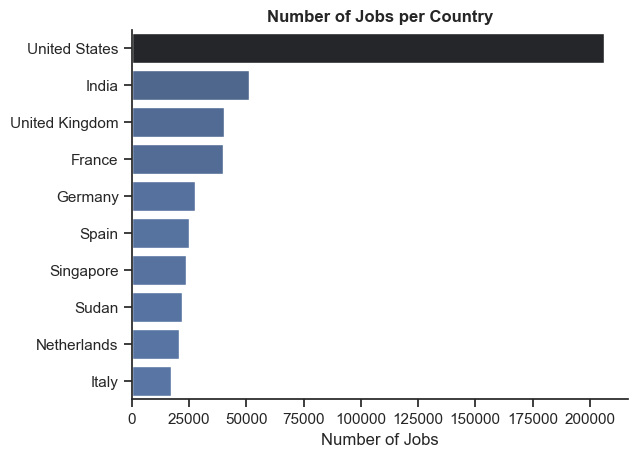

In [10]:
df_plot_head = df['job_country'].value_counts().to_frame().head(10)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot_head, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False)

plt.title('Number of Jobs per Country', fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('')
sns.despine()

# Companies to Explore

Global

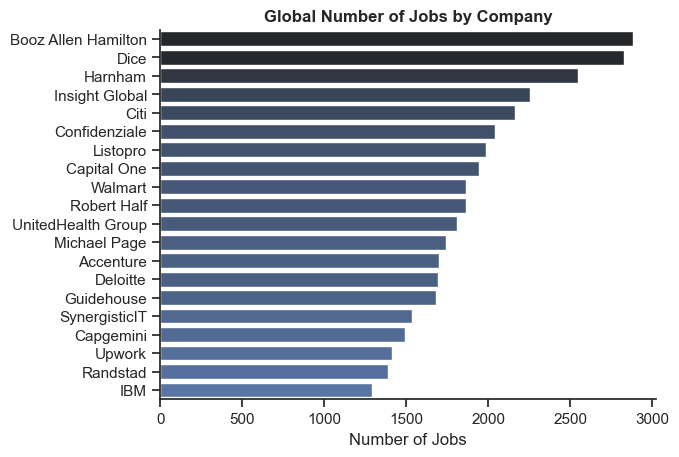

In [10]:
df_plot_company = df['company_name'].value_counts().to_frame()[1:].head(20)
#removed a fake recruitment site with top counts

sns.set_theme(style='ticks')
sns.barplot(data=df_plot_company, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)

plt.title('Global Number of Jobs by Company', fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('')
sns.despine()

Malaysia & Singapore

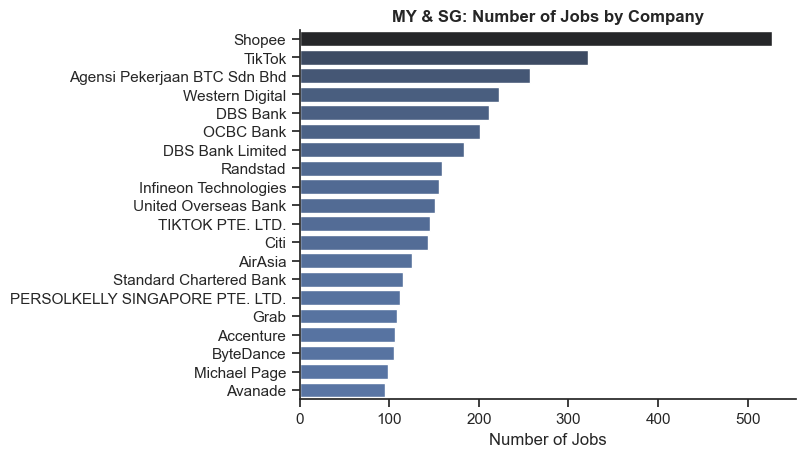

In [5]:
df_mysg = df[(df['job_country'] == 'Malaysia') | (df['job_country'] == 'Singapore')]

df_plot_company = df_mysg['company_name'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot_company, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)

plt.title('MY & SG: Number of Jobs by Company', fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('')
sns.despine()

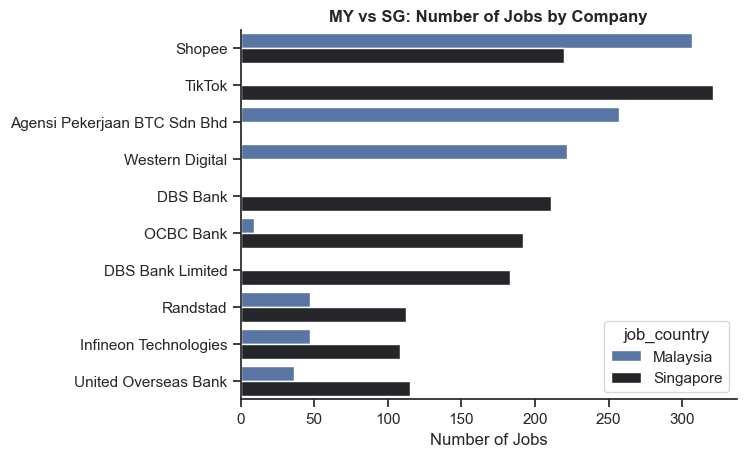

In [37]:
df_top_companies_mysg = (
    df_mysg['company_name']
    .value_counts()
    .head(10)
    .index
)

df_plot_company_mysg2 = (
    df_mysg[df_mysg['company_name'].isin(df_top_companies_mysg)]
    .groupby(['company_name', 'job_country'])
    .size()
    .reset_index(name='count')
)

company_order = (
    df_plot_company_mysg2
    .groupby('company_name')['count']
    .sum()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=df_plot_company_mysg2,
    x='count',
    y='company_name',
    order=company_order,
    hue='job_country',
    palette='dark:b_r'
)

plt.title('MY vs SG: Number of Jobs by Company', fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('')
sns.despine()

Malaysia

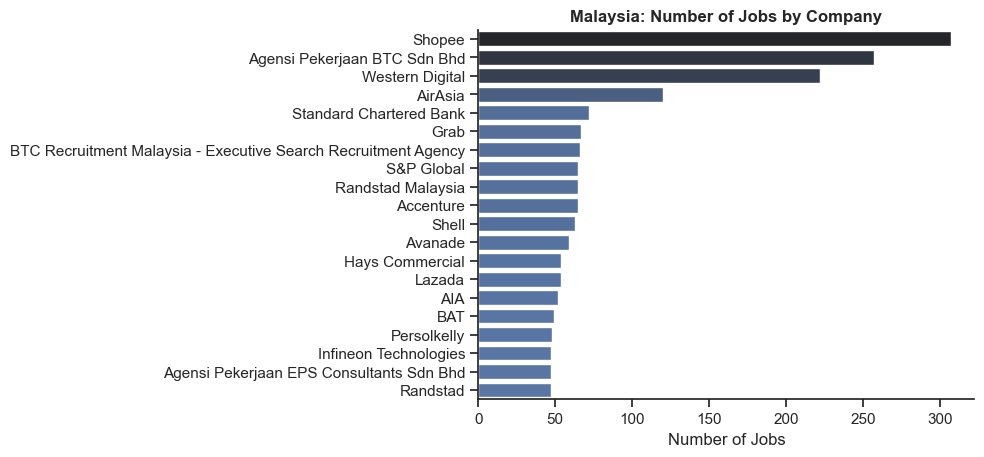

In [20]:
df_plot_company_my = df_my['company_name'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot_company_my, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)

plt.title('Malaysia: Number of Jobs by Company', fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('')
sns.despine()

# Job Requirement and Benefits

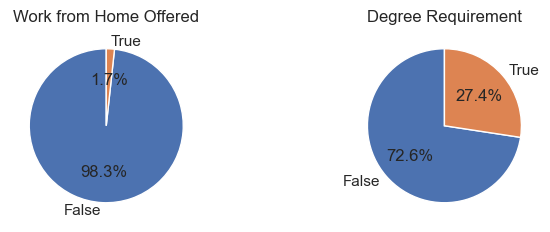

In [21]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement'
    # 'job_health_insurance': 'Health Insurance Offered' #MYSG all False
}


fig, ax=plt.subplots(1,2, figsize=(8,2.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_my[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

In [18]:
#Narrow Scope of data to Data and Business Analyst in Malaysia
df_role_my = df_my[(df_my['job_title_short'] == 'Data Analyst') | (df_my['job_title_short'] == 'Business Analyst')]

df_role_my

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
328,Data Analyst,Finance Data Analyst,"Sepang, Selangor, Malaysia",via Trabajo.org,Full-time,False,Malaysia,2023-07-14 13:11:55,True,False,Malaysia,None,NaN,NaN,AirAsia,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
1397,Data Analyst,Transfer Pricing Data Analyst,Malaysia,via BeBee Malaysia,Full-time,False,Malaysia,2023-08-18 13:29:59,False,False,Malaysia,None,NaN,NaN,KPMG PLT,"[sql, python, aws, gcp, azure, power bi, alter...","{'analyst_tools': ['power bi', 'alteryx', 'sap..."
1510,Data Analyst,Data Test Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-05-06 14:15:47,True,False,Malaysia,None,NaN,NaN,Agensi Pekerjaan BTC Sdn Bhd,"[sql, aws, azure, selenium, linux]","{'cloud': ['aws', 'azure'], 'libraries': ['sel..."
1568,Data Analyst,Metocean Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-07-10 13:10:20,False,False,Malaysia,None,NaN,NaN,Fugro,[python],{'programming': ['python']}
1861,Data Analyst,Reference Data Analyst - Client Account Services,Malaysia,via Jooble,Full-time,False,Malaysia,2023-09-10 13:24:16,False,False,Malaysia,None,NaN,NaN,JP Morgan Chase & Co.,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785254,Business Analyst,Business Analyst,"Shah Alam, Selangor, Malaysia",via Trabajo.org,Full-time,False,Malaysia,2023-11-17 06:20:50,False,False,Malaysia,None,NaN,NaN,EIG Management Service Sdn Bhd,[excel],{'analyst_tools': ['excel']}
785341,Data Analyst,Data Analyst Clerk,"Petaling Jaya, Selangor, Malaysia",via Trabajo.org,Full-time,False,Malaysia,2023-11-23 06:24:44,False,False,Malaysia,None,NaN,NaN,Advanced Agriecological Research Sdn Bhd,"[word, excel, powerpoint]","{'analyst_tools': ['word', 'excel', 'powerpoin..."
785397,Data Analyst,Data Analyst,Malaysia,via Trabajo.org,Full-time,False,Malaysia,2023-12-05 06:22:33,True,False,Malaysia,None,NaN,NaN,Hays,"[power bi, tableau, qlik]","{'analyst_tools': ['power bi', 'tableau', 'qli..."
785662,Business Analyst,Business Analysis and Intelligence Manager,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Trabajo.org,Full-time,False,Malaysia,2023-12-05 06:22:35,False,False,Malaysia,None,NaN,NaN,Denave (M) Sdn Bhd,"[sql, sql server, excel, word, power bi, power...","{'analyst_tools': ['excel', 'word', 'power bi'..."
